# Download library

In [ ]:
!pip install landscape_tools

# HDES Example

## Imports

In [1]:
import pickle
from Ansatze import *
from Cost_PSRhelpers import *
from Interpolation import *
from landscape_tools import landscape_visualization as lv
from Observable import *
from Plotter import *
from Run_optimization import *
from TestDe_sympy import *
from Utils import *

/home/gabriel/Desktop/dev/quick/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/gabriel/Desktop/dev/quick/venv/lib/python3.12/site-packages/vcs_versioning/_config.py:261: UserWarning: relative_to is expected to be a file, it's the directory /home/gabriel/Desktop/dev/quick/venv/lib/python3.12/site-packages
assuming the parent directory was passed
  return _check_absolute_root(self.root, self.relative_to)


In [2]:
from landscape_tools import barren_plateaus as bp
from landscape_tools import landscape_visualization as lv
from landscape_tools import exploratory_landscape_analysis as ela

## HDES Configuration

In [3]:
# - Differential equations and boundary conditions -
eq_func = poisson_equation_1D
BC_mode = "BC.SHIFT"  # "BC.SHIFT" for floatting boundary conditions or "BC.LOSS" for boundary condition terms in the cost function

# - Quantum circuit -
n_qubits = {"F_0": [5]}
depth = {"F_0": 3}
Ansatz = floquet_ansatz_generalized

# - Initial parameters -
## For Floquet ansatz:
hn1 = generate_h_list(
    n_qubits=sum(n_qubits["F_0"]), use_mode="3", phase="mbl", seed=2
)  # if use_mode != "3" or phase != "mbl" it needs to be changed in floquet_ansatz_generalized() as well (in Ansatze.py)
hn1 = np.insert(hn1, 0, 1)
original_params = {"F_0": hn1}
# For HEA:
# original_params = {
#     "F_0": np.random.uniform(0, 6.28, sum(n_qubits["F_0"]) * depth["F_0"] + 1)
# }

# - Observable -
obs_type = {"F_0": ObservableType.LOCAL_Y_direct_polynomial}
max_k_local_obs = {
    "F_0": {"x_0": 3}#, "x_1": 2}#, "x_2": 2}
}  # used if ObservableType.LOCAL_... Each value must be smaller or equal to the n_qubits per variable
max_k_mbl_obs = {
    "F_0": 4
}  # used if ObservableType.MBL_OBS. Each value must be smaller or equal to the n_qubits per function
funcs_to_decompositions_mapping = FunctionsToDecompositionsMapping.NORMAL

# - Output file -
_pkl_path = "run_data.pkl"
open(_pkl_path, "wb").close()


# ----------------------------------------------------------------------------------
# Preprocessing before optimization run
# ----------------------------------------------------------------------------------

# preprocessing equation group (interpolation for BCs if applicable)
differential_eqs_bcs, shift_derivatives_all = preprocessing_equation_group(
    BC_mode, eq_func
)
scaling_dict = create_scaling_dict(len(eq_func().variables))
x_values = np.linspace(0, 1, 50)  # collocation points
# preprocessing of collocation points
n_dim = len(eq_func().variables["F_0"]) - 1
x_list = [list(point) for point in product(x_values, repeat=n_dim)]

# preprocessing observable properties
observable_properties_dict = preprocessing_observable_properties(
    n_qubits, obs_type, max_k_local_obs, max_k_mbl_obs
)

# preprocessing observable
eq_obj = eq_func()
eq_obj.expressions = differential_eqs_bcs
new_coeff_matrices, isa_obs_list = generate_observable(
    x_list,
    eq_obj,
    n_qubits,
    observable_properties_dict,
    funcs_to_decompositions_mapping,
)

nb of spectral polynomials for the function/derivative under consideration =  25
Time: 0.0009021759033203125
nb of spectral polynomials for the function/derivative under consideration =  25
Time: 0.0006020069122314453


## Optimization

In [4]:
# - Optimization -
optimizers = ["trf"]  # optimizer choice "BFGS", "trf"...
max_iters = [100]
use_psr_list = [
    False
]  # parameter shift rule to evaluate gradients (not really usefull with "ideal" and "classical" run_mode) # TODO psr with BC.LOSS does not work

# - Simulator mode -
run_mode = "ideal"  # "ideal" (ideal simulator), "shot" (shot noise only), "fake" (hardware noises + shot noise) or "classical" (C-DES)
shots_list = [20000]
use_state_vector = True  # expectation value evaluation from state vector sampling (if True: accelerates runs when large n_qubits)

# transpilation of circuit and observable (no transpilation if run_mode = "ideal" or "shot")
circuits = generate_circuits(n_qubits, depth, Ansatz)
isa_circuits, isa_obs_trans = transpile(circuits, isa_obs_list, run_mode=run_mode)

# define the backend
backend = get_backend(run_mode)

Stage 1 (trf):  72%|███████▏  | 72/100 [00:30<00:11,  2.37iter/s, cost=73.3201]


→ Stage 1 (trf, shots=20000) done in 30.3s
     message: The maximum number of function evaluations is exceeded.
     success: False
      status: 0
         fun: [ 5.314e+00  3.282e+00 ... -2.766e-01 -2.736e-01]
           x: [ 5.711e+01 -2.114e+00 ...  1.784e+00 -2.103e-01]
        cost: 36.66019525461906
         jac: [[ 9.306e-02 -3.789e+01 ...  1.669e+01 -3.524e+02]
               [ 7.992e-02 -6.034e+01 ...  1.528e+01 -3.414e+02]
               ...
               [ 1.760e-02 -8.785e+02 ... -2.720e+02 -9.631e+03]
               [-4.792e-03 -6.171e+02 ... -2.284e+03 -2.493e+04]]
        grad: [ 3.377e-04  1.162e+02 ...  8.317e+02  1.000e+04]
  optimality: 10002.493478744198
 active_mask: [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
        nfev: 100
        njev: 73
     message: The maximum number of function evaluations is exceeded.
     success: False
      status: 0
         fun: [ 5.314e+00  3.282e+00 ... -2.766e-01 -2.736e-01]
           x: [ 5.711e+01 -2.114e+00 ...  1.7

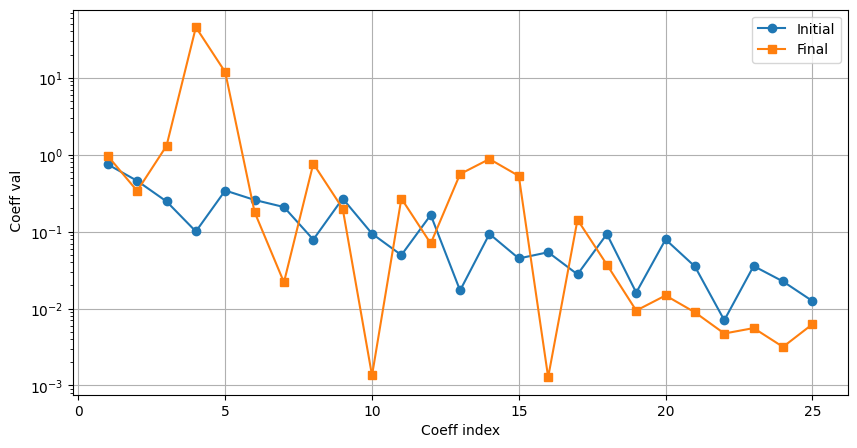

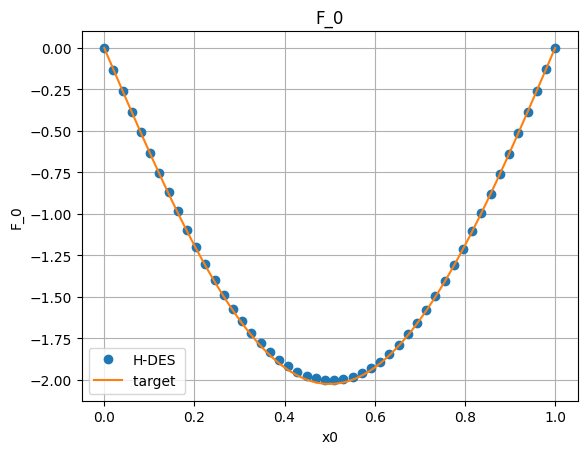

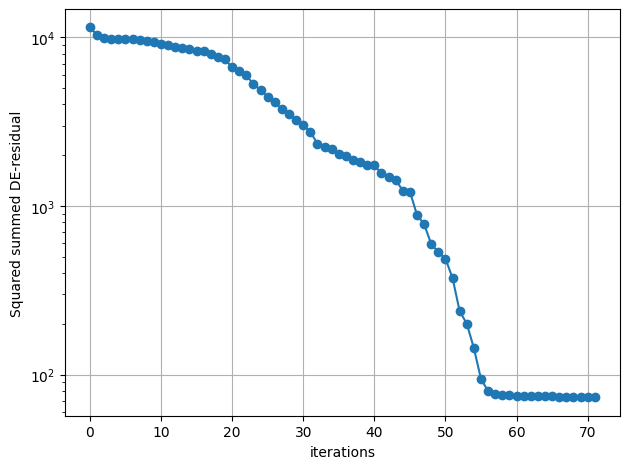

In [5]:
results = run_optimization(
    cost_function=cost_function,
    eq_func=eq_func,
    compute_psr_jacobian=compute_psr_jacobian,
    isa_circuits=isa_circuits,
    isa_obs_trans=isa_obs_trans,
    new_coeff_matrices=new_coeff_matrices,
    x_values=x_list,
    original_params=original_params,
    BC_mode=BC_mode,
    optimizers=optimizers,
    max_iters=max_iters,
    use_psr_list=use_psr_list,
    shots_list=shots_list,
    run_mode=run_mode,
    Ansatz=Ansatz,
    _pkl_path=_pkl_path,
    use_state_vector=use_state_vector,
    backend=backend,
)

print(results[0])

extract_coeffs(_pkl_path, n_qubits, observable_properties_dict)

plot_run_from_pkl(
    pkl_path=_pkl_path,
    eq_func=eq_func,
    x_list=x_list,
    scaling_dict=scaling_dict,
    shift_derivatives_all=shift_derivatives_all,
    n_dim=len(x_list[0]),
    BC_mode=BC_mode,
)
# plt.plot(np.abs(results[0].fun))
# plt.show()
plot_loss(_pkl_path)

# Cost function wrapping

In [8]:
def create_cost_value_function(
    use_state_vector: bool,
    isa_circuits: Dict,
    isa_obs_trans: Dict[str, List[Pauli]],
    new_coeff_matrices: Dict,
    x_list: List[List[tuple]] | List[List[float]],
    eq_func: Callable,
    run_mode: str,
    shots_list: List[int],
    original_params: Dict[str, npt.NDArray[np.float64]],
    BC_mode: str,
    backend,
) -> Callable:

    def f2(current_params):
        value, _, _, _, _, _ = cost_function(
            use_state_vector,
            current_params,
            isa_circuits,
            isa_obs_trans,
            new_coeff_matrices,
            x_list,
            eq_func,
            run_mode,
            shots_list,
            original_params,
            BC_mode,
            backend,
        )
        return value

    return f2

In [9]:
loss_value = create_cost_value_function(
    use_state_vector,
    isa_circuits,
    isa_obs_trans,
    new_coeff_matrices,
    x_list,
    eq_func,
    run_mode,
    shots_list,
    original_params,
    BC_mode,
    backend,
)

# Landscape Visualization

## Retrieve optimization trajectory

In [10]:
records = []
with open(_pkl_path, "rb") as f:
    while True:
        try:
            records.append(pickle.load(f))
        except EOFError:
            break
if not records:
    raise ValueError("Empty pickle file.")

param_history = []
for rec in records:
    params_dict = rec["params"]
    full_param = np.concatenate(list(params_dict.values()))
    param_history.append(full_param)

last_record = records[-1]
params_f = last_record["params"]

# Flatten parameters into a single vector (N,)
paramsf = np.concatenate(list(params_f.values()))

d1, d2 = lv.random_mixed_directions(len(np.concatenate(list(original_params.values()))))

## 1D Scan

1D scan progression: 100%|██████████| 300/300 [00:20<00:00, 14.90it/s]


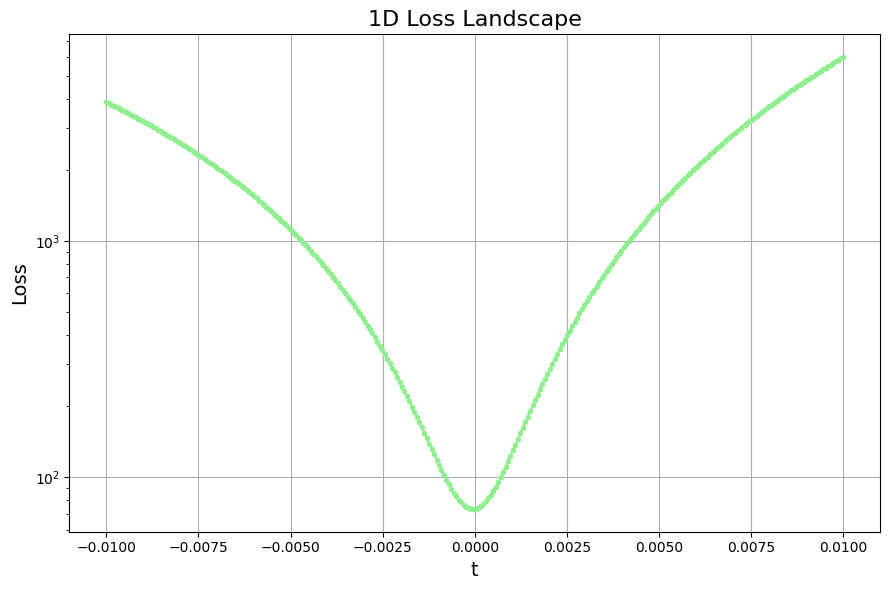

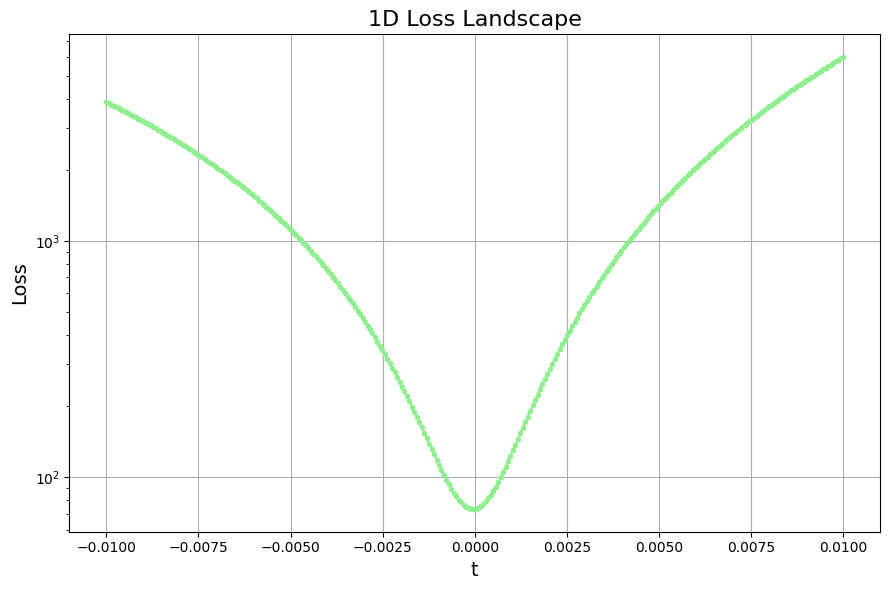

In [11]:
lv.loss_scan_1d(
    params=paramsf,
    direction=d1,
    loss_function=loss_value,
    n_steps=300,
    end_points=(-0.01, 0.01),
    n_jobs=-1
)

## 2D Scan

2D scan progression: 100%|██████████| 100/100 [00:32<00:00,  3.10it/s]


(<Figure size 900x600 with 2 Axes>, <Figure size 900x600 with 2 Axes>)

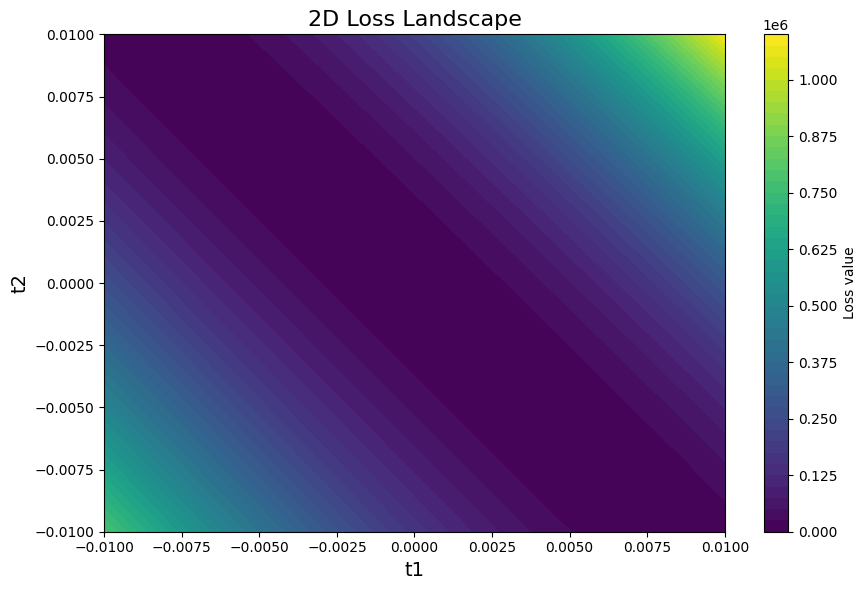

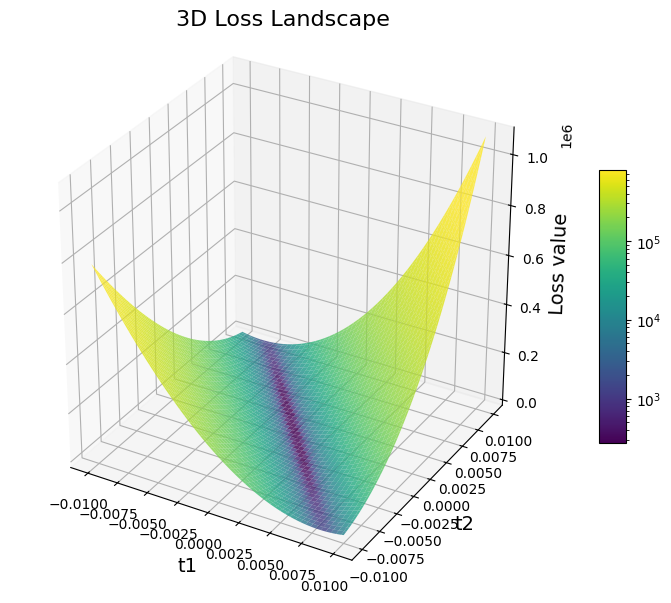

In [15]:
lv.loss_scan_2d_3d(
    params=paramsf,
    direction1=d1,
    direction2=d2,
    loss_function=loss_value,
    n_steps=100,
    end_points_x=(-0.01, 0.01),
    end_points_y=(-0.01, 0.01),
    plot3D=True,
    n_jobs=-1
)

## PCA Analysis


[PCA] Starting PCA-based loss landscape scan...


Trajectory loss: 100%|██████████| 72/72 [00:00<00:00, 95.71it/s] 


[PCA] Plotting 2D PCA loss landscape
[PCA] Plotting 3D PCA loss surface

[PCA] Computing interpretable PCA analysis...
[PCA] Visualizing parameter influence on real circuits


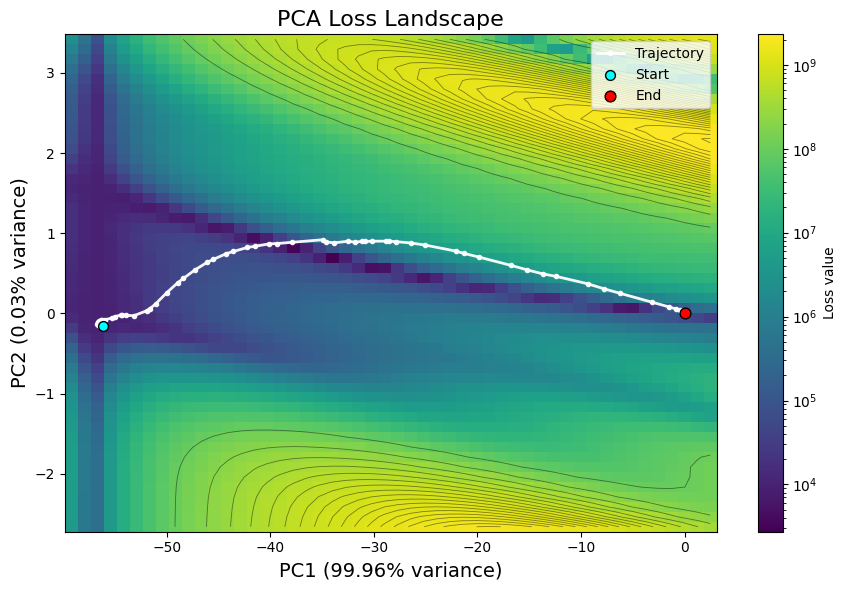

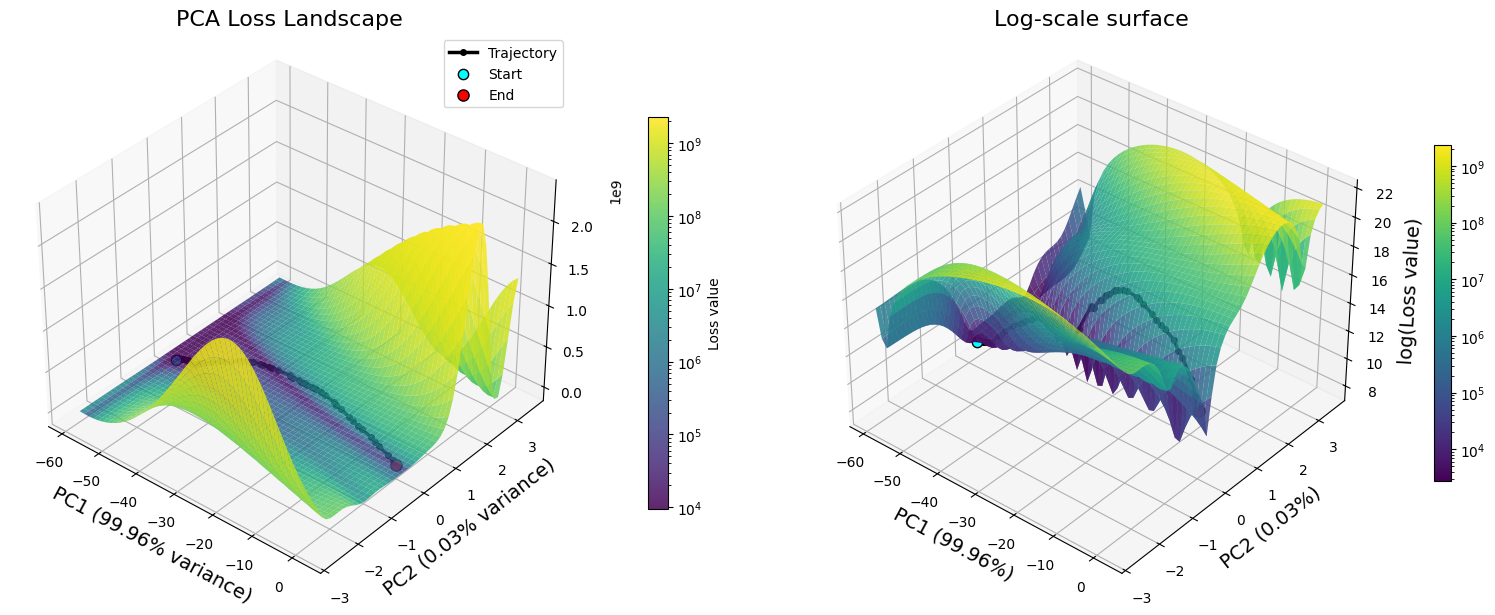

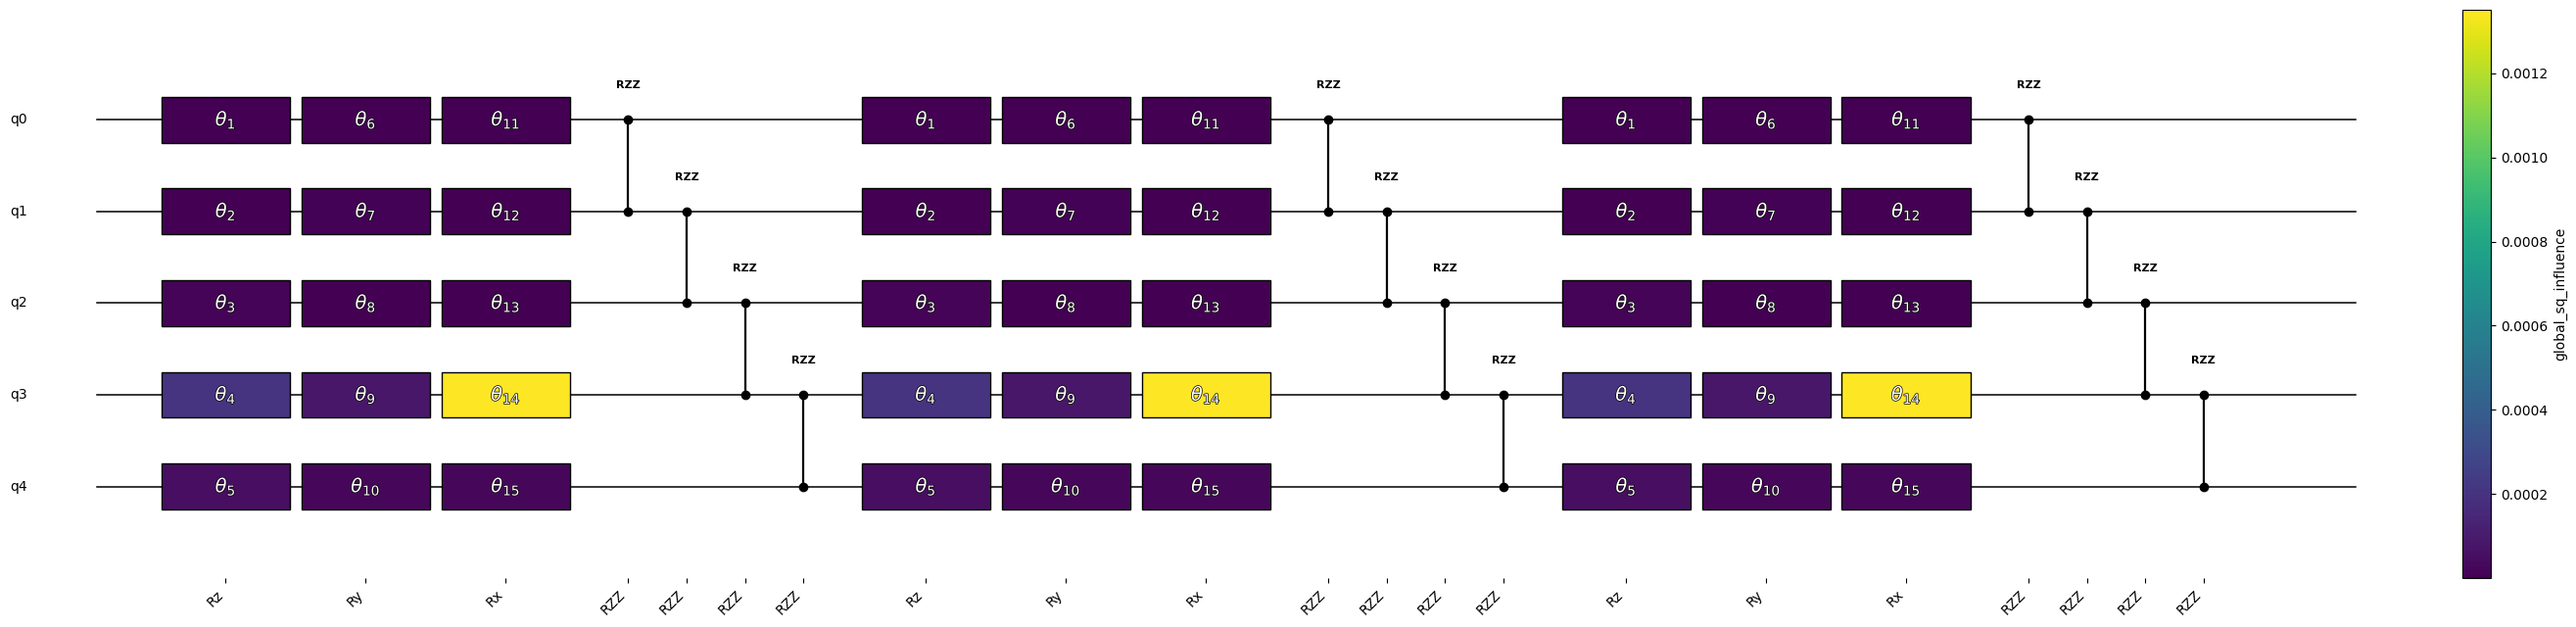

[PCA] Generating global PCA analysis figures
[PCA] Analysis completed


({'summary': {'n_steps': 72,
   'n_parameters': 16,
   'n_components_analyzed': 2,
   'explained_variance_ratio': array([9.99576243e-01, 3.49376816e-04]),
   'cumulative_explained_variance': array([0.99957624, 0.99992562]),
   'effective_rank_90pct': 1,
   'effective_rank_95pct': 1,
   'dominant_component': 0,
   'most_influential_parameters': [{'index': 0,
     'field': None,
     'local_index': 0,
     'label': '$\\theta_{0}$',
     'mean': 27.001848784783093,
     'std': 21.22017995520587,
     'range': 56.671569776043206,
     'path_length': 57.18827568032247,
     'global_abs_influence': 0.9989506773421487,
     'global_sq_influence': 0.9982271544593062,
     'global_path_influence': 57.128266726887645},
    {'index': 14,
     'field': None,
     'local_index': 14,
     'label': '$\\theta_{14}$',
     'mean': 1.1036100561132276,
     'std': 0.7813050552161993,
     'range': 1.9461420377342673,
     'path_length': 2.041332294603028,
     'global_abs_influence': 0.033038787766648335

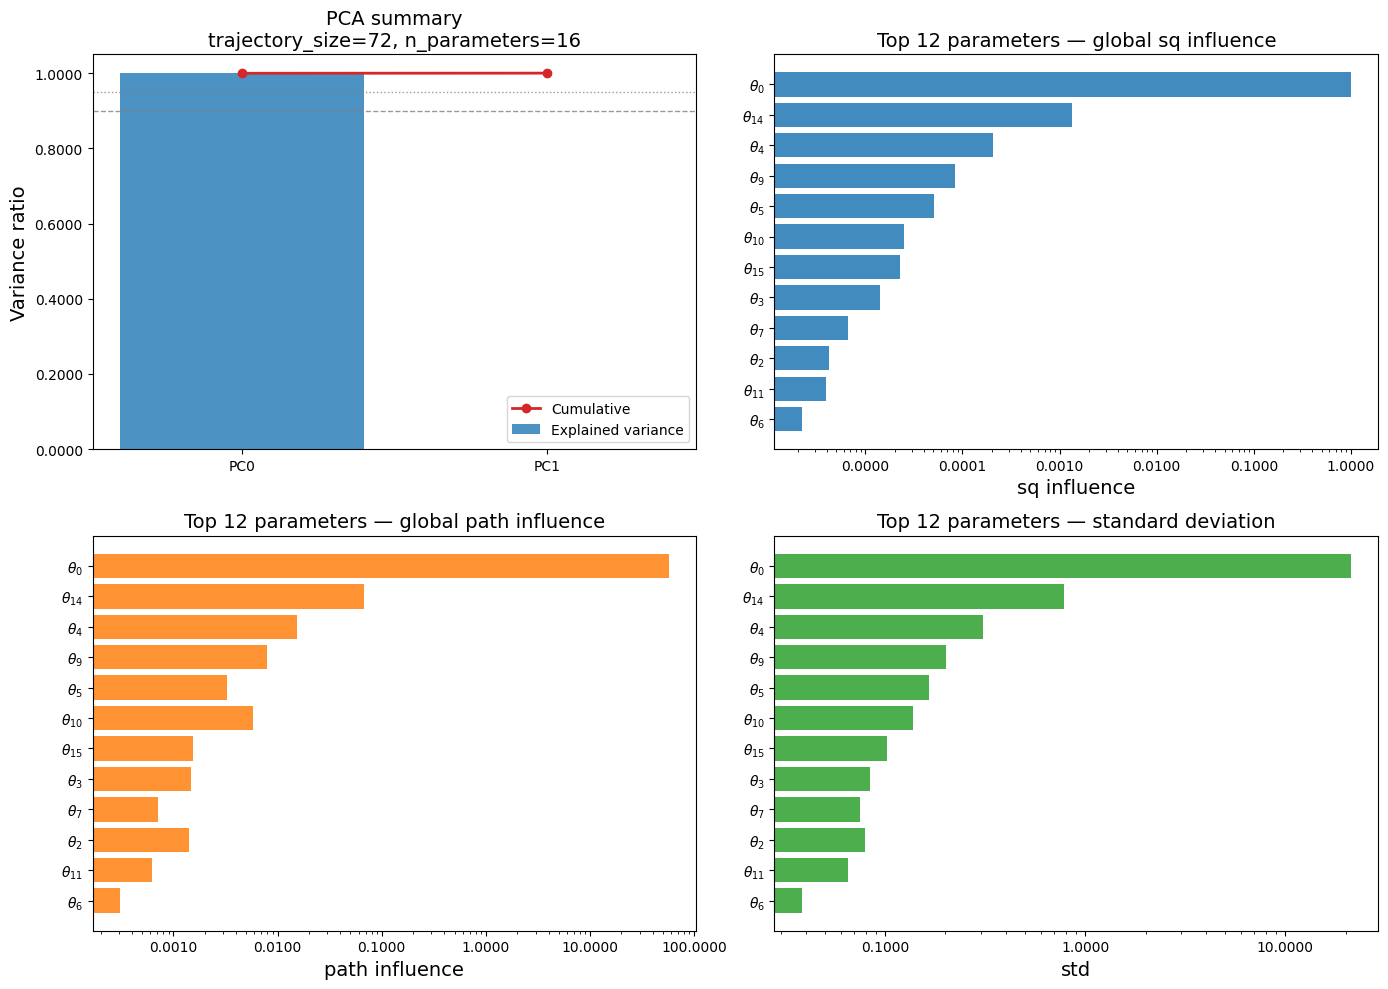

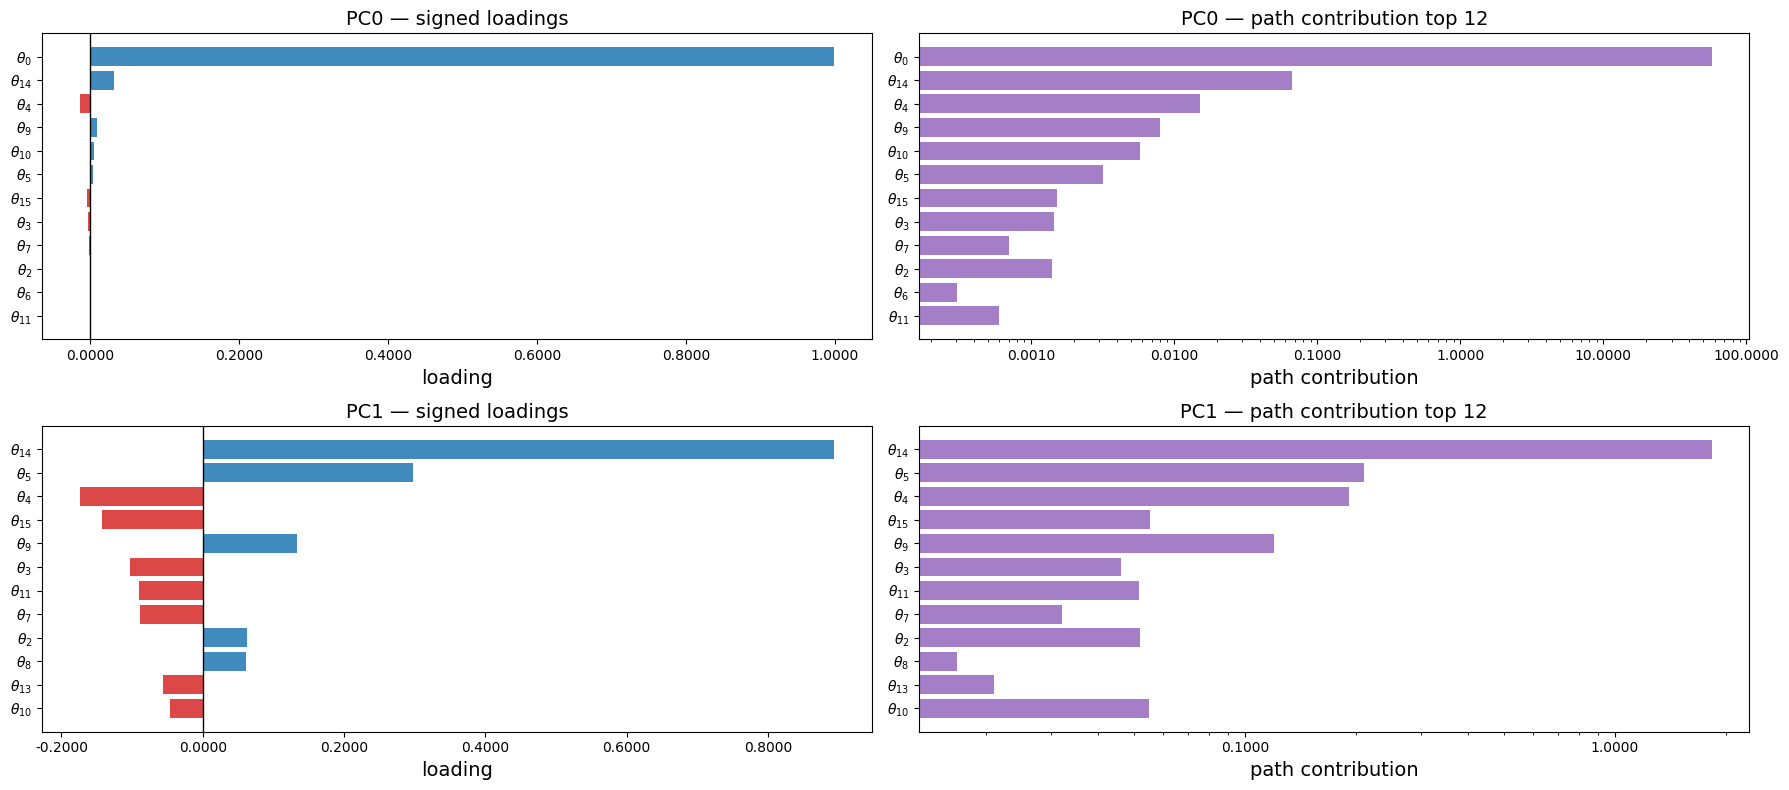

In [13]:
lv.perform_pca_and_analysis(
    param_history,
    loss_value,
    n_steps=50,
    offset=2.5,
    n_top=12,
    circuit=isa_circuits["F_0"]
)

# Barren Plateaus

## Helpers

In [19]:
def cost_function_exp(
    use_state_vector: bool,
    current_params: npt.NDArray[np.float64],
    isa_circuit,
    isa_obs_list: Pauli,
    run_mode: str,
    shots: int,
    backend,
):

    angles = current_params[1:]

    # Single Pauli observable
    pauli_string = str(isa_obs_list)

    # Single Walsh index
    pauli_monomial_index = pauli_to_index_zstring(pauli_string)

    if use_state_vector is False:

        estimator = get_estimator(run_mode, shots)

        pub = (isa_circuit, isa_obs_list, angles)

        result = estimator.run(pubs=[pub]).result()

        expectation_values = result[0].data.evs

    else:

        first_pauli_op = pauli_string.lstrip("I")[0]

        num_qubits = isa_circuit.num_qubits

        if len(pauli_string) != num_qubits:
            raise ValueError(
                f"Observable has {len(pauli_string)} qubits "
                f"but circuit has {num_qubits}"
            )

        if run_mode == "ideal":

            qc_wht = isa_circuit.assign_parameters(angles)

            rotate_for_paulis(
                qc_wht,
                [first_pauli_op] * num_qubits,
            )

            qc_wht.save_statevector()

            backend = AerSimulator(method="statevector")

            psi = backend.run(qc_wht).result().get_statevector()

            proba_density = np.abs(psi) ** 2

            expectation_value_all_pauli_monomials = (
                fast_walsh_transform(proba_density)
            )

            expectation_values = (
                expectation_value_all_pauli_monomials[
                    pauli_monomial_index
                ]
            )

        else:

            qc_wht = isa_circuit.copy()

            rotate_for_paulis(
                qc_wht,
                [first_pauli_op] * num_qubits,
            )

            qc_wht = qc_wht.assign_parameters(angles)

            qc_meas = qc_wht.copy()

            qc_meas.measure_all()

            job = backend.run(qc_meas, shots=shots)

            counts = job.result().get_counts()

            proba_dens_hat = counts_to_prob_vector(
                counts,
                num_qubits,
            )

            expectation_values = (
                expectations_for_indices_from_proba_density(
                    proba_dens_hat,
                    [pauli_monomial_index],
                )[0]
            )

    return expectation_values

def transpile_exp(
    circuit,
    isa_obs_list,
    run_mode="ideal",
    backend: Optional[AerSimulator] = None,
    optimization_level: int = 3,
    layout_method: str = "trivial",
):

    # No transpilation
    if run_mode.lower() in ("ideal", "shot", "none", "classical"):
        return circuit, isa_obs_list

    # Backend
    if backend is None:
        backend = AerSimulator()

    # Noise backend
    if run_mode.lower() in ("fake", "gatenoise"):
        noise_model = NoiseModel.from_backend(FakeAlgiers())
        backend = AerSimulator(noise_model=noise_model)

    # Pass manager
    preset_manager = generate_preset_pass_manager(
        optimization_level=optimization_level,
        backend=backend,
        layout_method=layout_method,
    )

    # Transpile circuit
    isa_circuit = preset_manager.run(circuit)

    # Apply layout to Pauli observable
    layout = isa_circuit.layout
    isa_obs_trans = isa_obs_list.apply_layout(layout=layout)

    return isa_circuit, isa_obs_trans

def generate_circuits_exp(
    n_qubits: int,
    depth: int,
    ansatz_function: Callable,
    **ansatz_options: Dict,
) -> QuantumCircuit:
    
    circuit = ansatz_function(
        "F_0",
        n_qubits,
        depth,
        **ansatz_options,
    )

    return circuit

def generate_params_exp(n_qubits, depth):

    n_params = n_qubits * depth + 1
    params = np.random.uniform(0, 2 * np.pi, n_params)
    
    # ## For Floquet ansatz:
    # hn1 = generate_h_list(
    #     n_qubits=n_qubits, use_mode="3", phase="mbl", seed= np.random.randint(1000000000)
    # )  # if use_mode != "3" or phase != "mbl" it needs to be changed in floquet_ansatz_generalized() as well (in Ansatze.py)
    # params = np.insert(hn1, 0, 1)

    return params

## Cost function builder

In [16]:
def my_cost_builder(context, **kwargs):

    circuits = context["circuits"]
    observables = context["observables"]
    isa_circuit, isa_obs = transpile_exp(
        circuits,
        observables,
        run_mode=kwargs["run_mode"],
    )

    def cost_only_params(current_params):
        
        return cost_function_exp(
            use_state_vector=kwargs["use_state_vector"],
            current_params=current_params,
            isa_circuit=isa_circuit,
            isa_obs_list=isa_obs,
            run_mode=kwargs["run_mode"],
            shots=kwargs["shots"],
            backend=kwargs["backend"],
        )

    return cost_only_params

## Experiments config

In [22]:
experiment1 = bp.ExperimentConfig(
    analysis_type="layerwise_qubits_padding",
    N_qubits=[2,4,6,8],
    N_layers=[2,2,5,7],
    ansatz_name=HEA_ry_cascade,
    initial_Pauli_string= Pauli('IZ'),
    padding_types=["I","linear_half"],
)

experiment2 = bp.ExperimentConfig(
    analysis_type="joint_scaling_padding",
    N_qubits=[2,4,6,8],
    N_layers=[2,3,3,4],
    ansatz_name=HEA_ry_cascade,
    initial_Pauli_string=Pauli('IZ'),
    padding_types=["linear_half"],
)

sampling = bp.SamplingConfig(
    bootstrap_B=500,
    rel_err_target=0.05,
    N_max=20000,
)

execution = bp.ExecutionConfig(
    verbose=True,
    n_jobs=10
)

## Run analysis

--------------------
Number of qubits: 2
Number of layers: 5
Padding type: I
Pauli string: IZ


[Adaptive sampling] N = 900 | relative error = 2.90%
[Adaptive sampling] Target reached with N_samples = 900 (relative error target reached)
var = 0.33448152797387176
--------------------
Number of qubits: 4
Number of layers: 5
Padding type: I
Pauli string: IIIZ


[Adaptive sampling] N = 900 | relative error = 3.79%
[Adaptive sampling] Target reached with N_samples = 900 (relative error target reached)
var = 0.17759768971800943
--------------------
Number of qubits: 6
Number of layers: 5
Padding type: I
Pauli string: IIIIIZ


[Adaptive sampling] N = 900 | relative error = 3.85%
[Adaptive sampling] Target reached with N_samples = 900 (relative error target reached)
var = 0.16973334152269437
--------------------
Number of qubits: 2
Number of layers: 5
Padding type: linear_half
Pauli string: IZ


[Adaptive sampling] N = 900 | relative error = 2.93%
[Adaptive sampling] Target reached with N_samples = 900 (relative error target reached)
var = 0.3300669942214345
--------------------
Number of qubits: 4
Number of layers: 5
Padding type: linear_half
Pauli string: IZIZ


...

[Adaptive sampling] N = 900 | relative error = 3.92%
[Adaptive sampling] Target reached with N_samples = 900 (relative error target reached)
var = 0.13425263143481272
--------------------
Number of qubits: 6
Number of layers: 7
Padding type: I
Pauli string: IIIIIZ


[Adaptive sampling] N = 900 | relative error = 4.27%
[Adaptive sampling] Target reached with N_samples = 900 (relative error target reached)
var = 0.09569396909734348
--------------------
Number of qubits: 2
Number of layers: 7
Padding type: linear_half
Pauli string: IZ


[Adaptive sampling] N = 900 | relative error = 3.06%
[Adaptive sampling] Target reached with N_samples = 900 (relative error target reached)
var = 0.3266405499167668
--------------------
Number of qubits: 4
Number of layers: 7
Padding type: linear_half
Pauli string: IZIZ


[Adaptive sampling] N = 900 | relative error = 4.03%
[Adaptive sampling] Target reached with N_samples = 900 (relative error target reached)
var = 0.11770111978221307
--------------------
Number of qubits: 6
Number of layers: 7
Padding type: linear_half
Pauli string: IIZZIZ


[Adaptive sampling] N = 900 | relative error = 4.51%
[Adaptive sampling] Target reached with N_samples = 900 (relative error target reached)
var = 0.033176860074062064


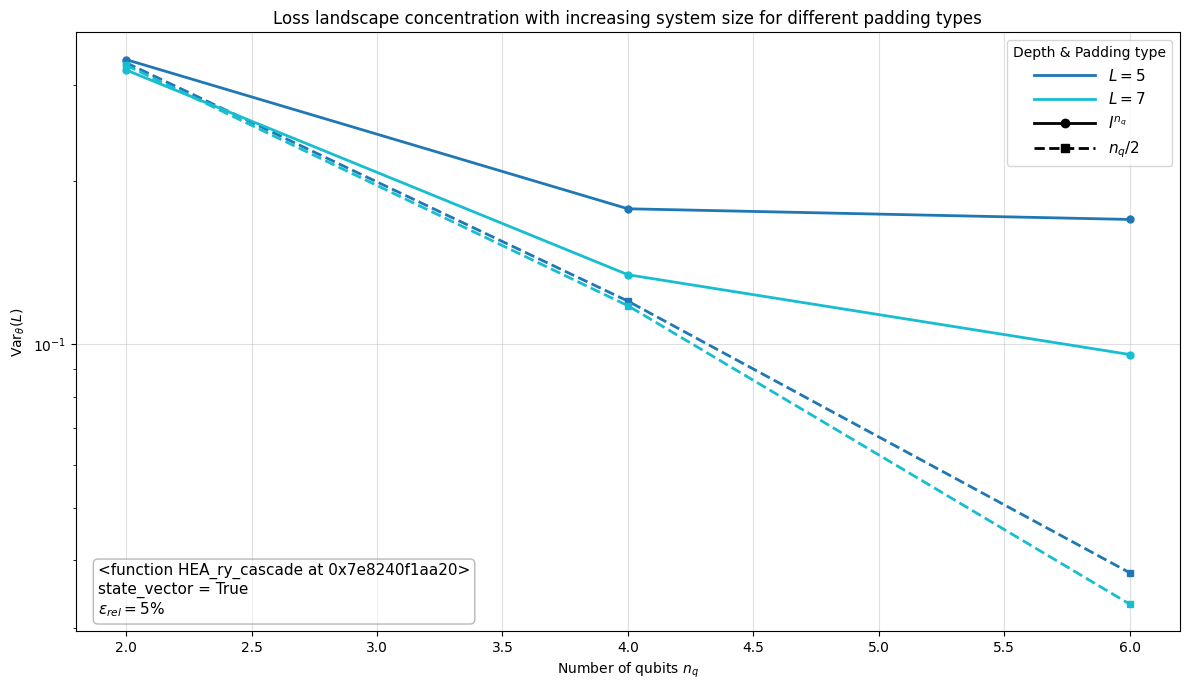

In [20]:
result1 = bp.barren_plateaus_analysis(
    experiment=experiment1,
    cost_function_builder=my_cost_builder,
    generate_params=generate_params_exp,
    generate_circuits=generate_circuits_exp,
    sampling=sampling,
    execution=execution,
    variance_normalization=None,
    
    # **cost_kwargs:
    use_state_vector=True,
    run_mode="ideal",
    shots=None,
    backend=get_backend("ideal"),
)

--------------------
Number of qubits: 2
Number of layers: 2
Padding type: linear_half
Pauli string: IZ


[Adaptive sampling] N = 900 | relative error = 2.93%
[Adaptive sampling] Target reached with N_samples = 900 (relative error target reached)
var = 0.3864490299654832
--------------------
Number of qubits: 4
Number of layers: 3
Padding type: linear_half
Pauli string: IZIZ


[Adaptive sampling] N = 900 | relative error = 4.05%
[Adaptive sampling] Target reached with N_samples = 900 (relative error target reached)
var = 0.1292542740161691
--------------------
Number of qubits: 6
Number of layers: 3
Padding type: linear_half
Pauli string: IIZZIZ


[Adaptive sampling] N = 900 | relative error = 5.66%
[Adaptive sampling] Adding 486 samples (N: 900 -> 1386)


[Adaptive sampling] N = 1386 | relative error = 4.59%
[Adaptive sampling] Target reached with N_samples = 1386 (relative error target reached)
var = 0.06398953478823094
--------------------
Number of qubits: 8
Number of layers: 4
Padding type: linear_half
Pauli string: IIIZZZIZ


[Adaptive sampling] N = 900 | relative error = 6.56%
[Adaptive sampling] Adding 959 samples (N: 900 -> 1859)


[Adaptive sampling] N = 1859 | relative error = 4.60%
[Adaptive sampling] Target reached with N_samples = 1859 (relative error target reached)
var = 0.020124771818745554


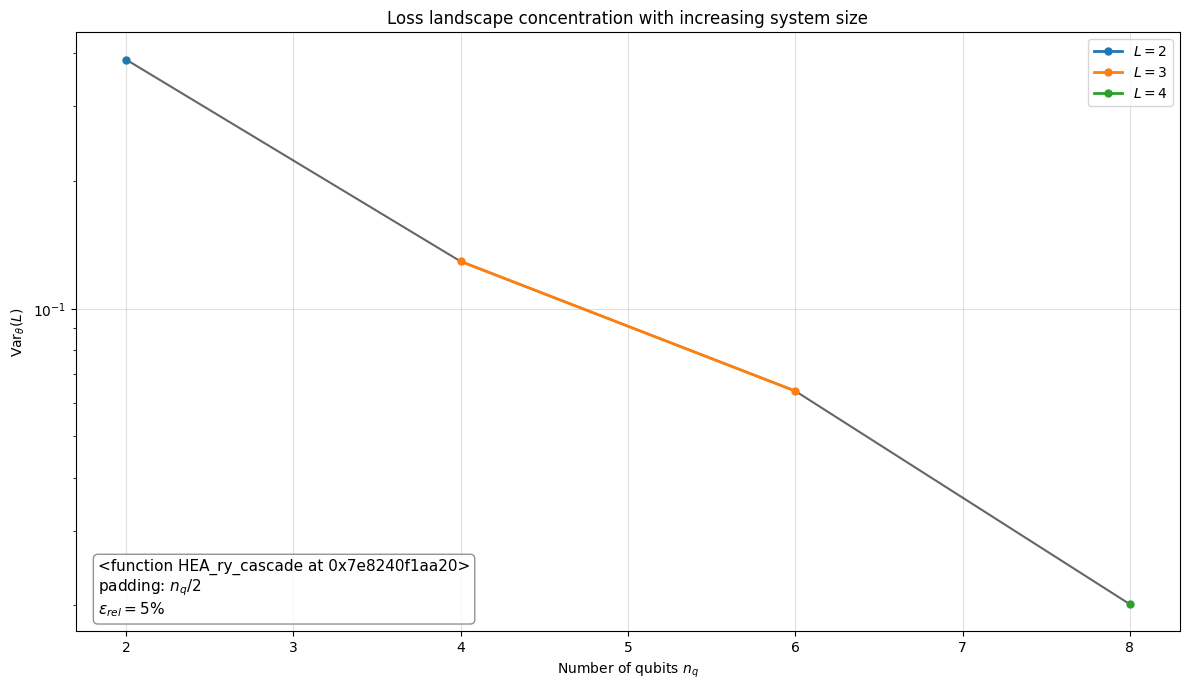

In [23]:
result2 = bp.barren_plateaus_analysis(
    experiment=experiment2,
    cost_function_builder=my_cost_builder,
    generate_params=generate_params_exp,
    generate_circuits=generate_circuits_exp,
    sampling=sampling,
    execution=execution,
    variance_normalization=None,
    
    # **cost_kwargs:
    use_state_vector=True,
    run_mode="ideal",
    shots=None,
    backend=get_backend("ideal")
)

# ELA

## Helpers

In [27]:
def generate_params(n_qubits, depth):

    # n_params = n_qubits * depth + 1
    # params = np.random.uniform(0, 2 * np.pi, n_params)
    
    ## For Floquet ansatz:
    hn1 = generate_h_list(
        n_qubits=sum(n_qubits["F_0"]), use_mode="3", phase="mbl", seed= np.random.randint(1000000000)
    )  # if use_mode != "3" or phase != "mbl" it needs to be changed in floquet_ansatz_generalized() as well (in Ansatze.py)
    params = np.insert(hn1, 0, 1)

    return params

def sample_once():
    theta = generate_params(n_qubits, depth)
    return theta

In [28]:
def make_compute_hessian(loss_value, step=None, method="central"):

    import numdifftools as nd

    def safe_loss(theta):
        try:
            theta = np.asarray(theta, dtype=np.float64)
            y = loss_value(theta)

            if np.isfinite(y):
                return float(y)

            return np.nan

        except Exception:
            return np.nan

    def compute_hessian(theta, indices=None):
        theta = np.asarray(theta, dtype=np.float64)

        if indices is None:
            indices = np.arange(theta.size)
        else:
            indices = np.asarray(indices, dtype=int)

        theta0 = theta.copy()
        z0 = theta0[indices].copy()

        def restricted_loss(z):
            theta_full = theta0.copy()
            theta_full[indices] = z
            return safe_loss(theta_full)

        if step is None:
            H = nd.Hessian(
                restricted_loss,
                method=method
            )(z0)
        else:
            H = nd.Hessian(
                restricted_loss,
                step=step,
                method=method
            )(z0)

        H = np.asarray(H, dtype=np.float64)
        H = 0.5 * (H + H.T)

        return H

    return compute_hessian

compute_hessian = make_compute_hessian(
    loss_value,
    step=None,          # ou par exemple step=1e-4
    method="central"
)

## Run analysis

In [29]:
features = ela.ela_difficulty(
    sample_once=sample_once,
    loss_value=loss_value,
    max_pairs=5000,
    compute_hessian=compute_hessian,
    n_curvature_points=32,
    curvature_dims=5,
    n_jobs=-1,
    verbose=True
)

display(features)

                                                                                 
Stage 1 (trf):   0%|          | 37/10000 [1:55:48<28:25,  5.84iter/s, cost=1972.75]

[ELA] N=1024, y_scale=2.049e+05, relative_change=2.009e-02


                                                                                   
Stage 1 (trf):   0%|          | 37/10000 [1:55:51<28:25,  5.84iter/s, cost=1972.75]

[ELA] N=1536, y_scale=2.098e+05, relative_change=2.391e-02


                                                                                   
Stage 1 (trf):   0%|          | 37/10000 [1:55:55<28:25,  5.84iter/s, cost=1972.75]

...

[ELA] N=3584, y_scale=2.164e+05, relative_change=3.046e-02


[ELA] N=4096, y_scale=2.218e+05, relative_change=2.494e-02
[ELA] Global sampling completed:
      final y_scale            = 2.217955e+05
      last relative change     = 2.494e-02

[ELA] y_scale may not be fully stable at N_max=4096. Consider increasing N_max because the maximum relative change over the last 2 checks is 3.046e-02, above rel_tol=2.000e-02.


Computing topology features...


            Section                                      Metric        Value                                                                      Description
          Convexity                   Convex violation fraction     0.441000                              Fraction of sampled segments that violate convexity
          Convexity                         Mean normalized gap    -0.015128                                                   Mean of normalized gap values.
          Convexity                                    Mean gap -3355.423534                                                               Mean of gap values
          Convexity                       Median normalized gap    -0.020406                                                 Median of normalized gap values.
          Convexity                                  Median gap -4526.066896                                                             Median of gap values
          Curvature           Hessian condition numb

,Section,Metric,Value,Description
0,Convexity,Convex violation fraction,0.441000,Fraction of sampled segments that violate conv...
1,Convexity,Mean normalized gap,-0.015128,Mean of normalized gap values.
2,Convexity,Mean gap,-3355.423534,Mean of gap values
3,Convexity,Median normalized gap,-0.020406,Median of normalized gap values.
4,Convexity,Median gap,-4526.066896,Median of gap values
5,Curvature,Hessian condition number (median),50.440184,Median ratio max(abs(lambda))/min(abs(lambda))...
6,Curvature,Hessian condition number (max),8011.000069,Maximum ratio max(abs(lambda))/min(abs(lambda)...
7,Curvature,Normalized Hessian spectral radius (median),1377.479919,Median largest absolute Hessian eigenvalue nor...
8,Curvature,Normalized Hessian spectral radius (max),9174.516921,Maximum largest absolute Hessian eigenvalue no...
9,Curvature,Negative eigenvalue fraction (median),0.600000,Median fraction of significantly negative Hess...
